In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r'/Users/anirudhiyer/Desktop/Minor_Project_OPS/Data/final_data.csv')

In [3]:
df.head()

,Age,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,...,Q27,Q28,Q29,Q30,Q31,Q32,Q33,Q34,Q35,final_label
0,19,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,3.0,...,0,0,0,1.0,0,1.0,1,0,1,0
1,18,4.0,3.0,3.0,3.0,3.0,1.0,1.0,1.0,2.0,...,0,0,0,1.0,0,1.0,1,0,1,0
2,20,4.0,4.0,4.0,3.0,2.0,2.0,2.0,3.0,0.0,...,0,0,0,1.0,0,1.0,1,0,1,0
3,19,3.0,2.0,4.0,2.0,3.0,3.0,2.0,3.0,1.0,...,0,0,0,1.0,0,1.0,1,0,1,1
4,19,3.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,...,0,0,0,1.0,0,1.0,1,0,1,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 37 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          858 non-null    int64  
 1   Q1           858 non-null    float64
 2   Q2           858 non-null    float64
 3   Q3           858 non-null    float64
 4   Q4           858 non-null    float64
 5   Q5           858 non-null    float64
 6   Q6           858 non-null    float64
 7   Q7           858 non-null    float64
 8   Q8           858 non-null    float64
 9   Q9           858 non-null    float64
 10  Q10          858 non-null    float64
 11  Q11          858 non-null    float64
 12  Q12          858 non-null    float64
 13  Q13          858 non-null    float64
 14  Q14          858 non-null    float64
 15  Q15          858 non-null    float64
 16  Q16          858 non-null    float64
 17  Q17          858 non-null    float64
 18  Q18          858 non-null    float64
 19  Q19     

<Axes: xlabel='final_label', ylabel='count'>

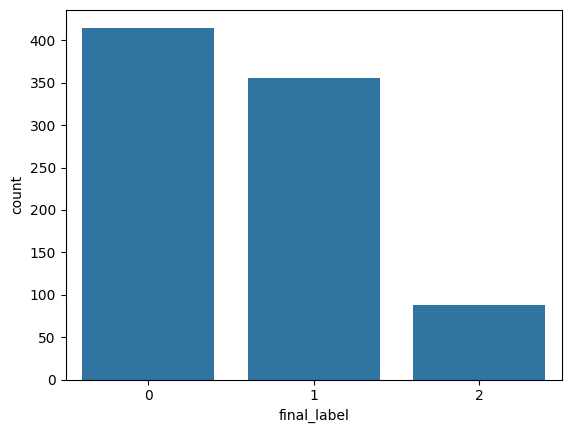

In [5]:
sns.countplot(x=df['final_label'])

In [6]:
pip install imblearn

     |████████████████████████████████| 235 kB 3.1 MB/s eta 0:00:01
You should consider upgrading via the '/Users/anirudhiyer/Desktop/Minor_Project_OPS/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [7]:
from imblearn.combine import SMOTEENN

In [8]:
enn=SMOTEENN(random_state=42)

X = df.drop('final_label', axis=1)
y = df['final_label']


senn = SMOTEENN(random_state=42)

X_resampled, y_resampled = enn.fit_resample(X, y)

df_senn = pd.DataFrame(X_resampled, columns=X.columns)
df_senn['final_label'] = y_resampled

In [9]:
df_senn.head()

,Age,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,...,Q27,Q28,Q29,Q30,Q31,Q32,Q33,Q34,Q35,final_label
0,19,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,3.0,...,0,0,0,1.0,0,1.0,1,0,1,0
1,20,4.0,4.0,4.0,3.0,2.0,2.0,2.0,3.0,0.0,...,0,0,0,1.0,0,1.0,1,0,1,0
2,19,3.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,...,0,0,0,1.0,0,1.0,1,0,1,0
3,20,4.0,3.0,3.0,3.0,4.0,2.0,1.0,1.0,2.0,...,0,0,0,1.0,0,1.0,1,1,1,0
4,19,3.0,2.0,1.0,4.0,1.0,1.0,1.0,2.0,0.0,...,0,0,0,1.0,0,1.0,1,0,1,0


In [10]:

from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,max_depth=5,min_samples_split=3)

In [11]:
from sklearn.model_selection import train_test_split

In [19]:
X=df_senn.drop(columns=['final_label'])
y=df_senn['final_label']

In [20]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [21]:
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,3
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
y_pred=rf.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,cohen_kappa_score,confusion_matrix,classification_report

In [24]:
acc=accuracy_score(y_pred,y_test)
pre=precision_score(y_pred,y_test,average='weighted')

f1=f1_score(y_pred,y_test,average='weighted')
rec=recall_score(y_pred,y_test,average='weighted')
coe=cohen_kappa_score(y_pred,y_test)

In [25]:
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {pre:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"Cohen Score:{coe:.4f}")

Accuracy  : 0.9791
Precision : 0.9790
Recall    : 0.9791
F1 Score  : 0.9790
Cohen Score:0.9673


In [27]:
pip install lightgbm

     |████████████████████████████████| 1.6 MB 3.7 MB/s eta 0:00:01
You should consider upgrading via the '/Users/anirudhiyer/Desktop/Minor_Project_OPS/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [28]:
import lightgbm as lgb

In [29]:
params = {
    'objective': 'multiclass',
    'num_class':3,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.1,
    'feature_fraction': 0.9
}

In [30]:
model=lgb.LGBMClassifier(**params)

In [31]:
model.fit(X_train,y_train)

[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000419 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1622
[LightGBM] [Info] Number of data points in the train set: 764, number of used features: 36
[LightGBM] [Info] Start training from score -0.986079
[LightGBM] [Info] Start training from score -1.627932
[LightGBM] [Info] Start training from score -0.842510
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Wa

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [32]:
y_pred=model.predict(X_test)

[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1  = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {pre:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.9843
Precision : 0.9849
Recall    : 0.9843
F1 Score  : 0.9841
